# Analysis of in vivo data

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats
import os
from adjustText import adjust_text
import matplotlib.patheffects as PathEffects
import warnings
warnings.filterwarnings('ignore')
plt.rc('font', family='Helvetica')

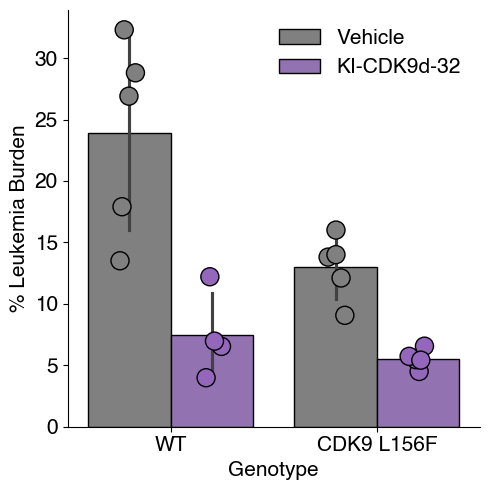

In [ ]:
a = pd.read_excel('../../source_data/05_flow_data/Cdk9 L156F  B-ALL Transplantation Experiment 19 .xlsx.xls', 'Sheet2')

#WT_PROTAC = np.asarray(a['WT PROTAC'])
#WT_Vehicle = np.asarray(a['WT Vehicle'])



#normed_wt = np.asarray(WT_PROTAC)/np.average(WT_Vehicle)

#normed_CDK9 = np.asarray(CDK9_PROTAC)/np.average(CDK9_Vehicle)

fig, ax = plt.subplots(figsize=(5,5))

sns.barplot(data=a, x='Genotype', y='Leukemia Burden', hue='Treatment',edgecolor='black', linewidth=1,errorbar='sd', palette=['grey', 'tab:purple'])
sns.stripplot(data=a, x='Genotype', y='Leukemia Burden', hue='Treatment', dodge=True, edgecolor='black', linewidth=1, size=13, legend=False,palette=['grey', 'tab:purple'])

ax.legend(loc='upper right', fontsize=15, frameon=False)
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Genotype', fontsize=15)
ax.set_ylabel('% Leukemia Burden', fontsize=15)
fig.tight_layout()
#fig.savefig('../../figures/invivo_CDK9_1.pdf', transparent=True)

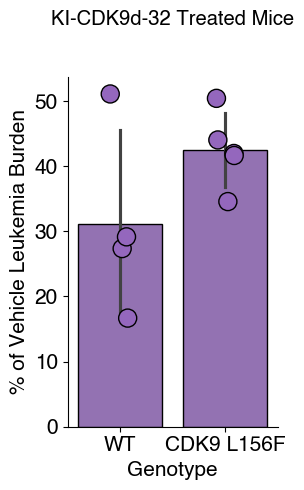

In [ ]:
avg_wt = np.average(a[(a['Genotype']=='WT') & (a['Treatment']=='Vehicle')]['Leukemia Burden'])
avg_mut = np.average(a[(a['Genotype']=='CDK9 L156F') & (a['Treatment']=='Vehicle')]['Leukemia Burden'])

normed_wt = 100*np.asarray(a[(a['Genotype']=='WT') & (a['Treatment']=='KI-CDK9d-32')]['Leukemia Burden'])/avg_wt
normed_mut = 100*np.asarray(a[(a['Genotype']=='CDK9 L156F') & (a['Treatment']=='KI-CDK9d-32')]['Leukemia Burden'])/avg_mut

g = ['WT']*len(normed_wt) + ['CDK9 L156F']*len(normed_mut)

d2 = pd.DataFrame(dict(zip(['Genotype', '% of Vehicle Leukemia Burden'], [g, list(normed_wt) + list(normed_mut)])))

fig, ax = plt.subplots(figsize=(3,5))

sns.barplot(data=d2, x='Genotype', y='% of Vehicle Leukemia Burden', edgecolor='black', linewidth=1,errorbar='sd', palette=['tab:purple'])
sns.stripplot(data=d2, x='Genotype', y='% of Vehicle Leukemia Burden',  dodge=False, edgecolor='black', linewidth=1, size=13, legend=False,palette=['tab:purple'])

ax.legend(loc='upper right', fontsize=15, frameon=False)
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Genotype', fontsize=15)
ax.set_ylabel('% of Vehicle Leukemia Burden', fontsize=15)
ax.set_title('KI-CDK9d-32 Treated Mice\n\n', fontsize=14.5)
fig.tight_layout()
#fig.savefig('../../figures/invivo_CDK9_normed.pdf', transparent=True)

In [45]:
t_statistic, p_value = scipy.stats.ttest_ind(normed_wt, normed_mut)
print(p_value)

0.14403765124698595


In [54]:
scipy.stats.ttest_ind(a[(a['Genotype']=='CDK9 L156F') & (a['Treatment']=='KI-CDK9d-32')]['Leukemia Burden'], a[(a['Genotype']=='WT') & (a['Treatment']=='KI-CDK9d-32')]['Leukemia Burden'])

Ttest_indResult(statistic=-1.2136474886516635, pvalue=0.2642381386736925)

# CDK7 analysis

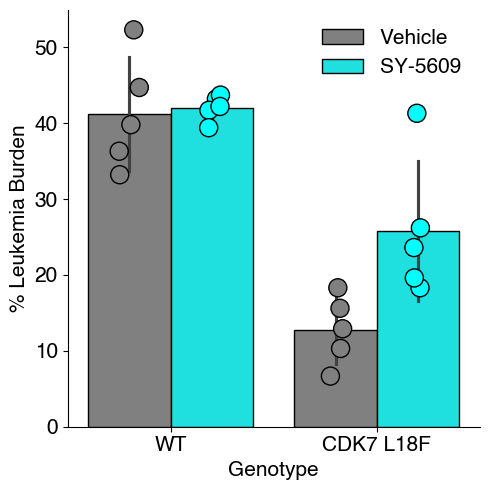

In [ ]:
a = pd.read_excel('../../source_data/05_flow_data/B-ALL mCdk7 L18F SY-5609 Competition D10.xls', 'Sheet1')

fig, ax = plt.subplots(figsize=(5,5))

sns.barplot(data=a, x='Genotype', y='Leukemia Burden', hue='Treatment',edgecolor='black', linewidth=1,errorbar='sd', palette=['grey', 'cyan'])
sns.stripplot(data=a, x='Genotype', y='Leukemia Burden', hue='Treatment', dodge=True, edgecolor='black', linewidth=1, size=13, legend=False,palette=['grey', 'cyan'])

ax.legend(loc='upper right', fontsize=15, frameon=False)
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Genotype', fontsize=15)
ax.set_ylabel('% Leukemia Burden', fontsize=15)
fig.tight_layout()
#fig.savefig('../../figures/invivo_CDK7.pdf', transparent=True)

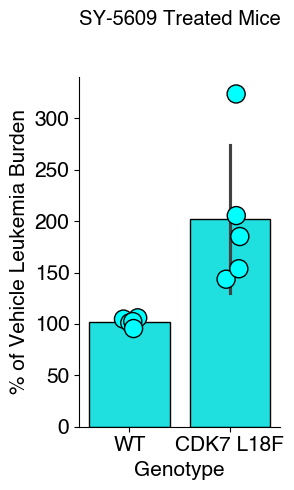

In [ ]:
avg_wt = np.average(a[(a['Genotype']=='WT') & (a['Treatment']=='Vehicle')]['Leukemia Burden'])
avg_mut = np.average(a[(a['Genotype']=='CDK7 L18F') & (a['Treatment']=='Vehicle')]['Leukemia Burden'])

normed_wt = 100*np.asarray(a[(a['Genotype']=='WT') & (a['Treatment']=='SY-5609')]['Leukemia Burden'])/avg_wt
normed_mut = 100*np.asarray(a[(a['Genotype']=='CDK7 L18F') & (a['Treatment']=='SY-5609')]['Leukemia Burden'])/avg_mut

g = ['WT']*len(normed_wt) + ['CDK7 L18F']*len(normed_mut)

d2 = pd.DataFrame(dict(zip(['Genotype', '% of Vehicle Leukemia Burden'], [g, list(normed_wt) + list(normed_mut)])))

fig, ax = plt.subplots(figsize=(3,5))

sns.barplot(data=d2, x='Genotype', y='% of Vehicle Leukemia Burden', edgecolor='black', linewidth=1,errorbar='sd', palette=['cyan'])
sns.stripplot(data=d2, x='Genotype', y='% of Vehicle Leukemia Burden',  dodge=False, edgecolor='black', linewidth=1, size=13, legend=False,palette=['cyan'])

ax.legend(loc='upper right', fontsize=15, frameon=False)
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=15)
ax.set_xlabel('Genotype', fontsize=15)
ax.set_ylabel('% of Vehicle Leukemia Burden', fontsize=15)
ax.set_title('SY-5609 Treated Mice\n\n', fontsize=14.5)
fig.tight_layout()
#fig.savefig('../../figures/invivo_CDK7_normed.pdf', transparent=True)

In [11]:
t_statistic, p_value = scipy.stats.ttest_ind(normed_wt, normed_mut)
print(p_value)

0.014631859523773829


In [17]:
scipy.stats.ttest_ind(a[(a['Genotype']=='CDK7 L18F') & (a['Treatment']=='SY-5609')]['Leukemia Burden'], a[(a['Genotype']=='CDK7 L18F') & (a['Treatment']=='Vehicle')]['Leukemia Burden'])

Ttest_indResult(statistic=2.8406256219052652, pvalue=0.021790983195037125)